<a href="https://colab.research.google.com/github/na2003-gif/E-business-index_projectbyNaphan/blob/main/EBI110325_MedE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip -q install geopandas matplotlib mapclassify
!pip -q install geodatasets
!pip -q install linearmodels
!pip -q install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.8 MB/s eta 0:00:00


# Data Cleaning

In [5]:
import pandas as pd
file_path = '/content/EBI.5y.In.xlsx'
df = pd.read_excel(file_path)
display(df.head())
import numpy as np
df['ln_PBR'] = np.log1p(df['PBR'])
df['ln_GRDP'] = np.log1p(df['GRDP'])
df['ln_POP'] = np.log1p(df['POP'])
df['ln_In'] = np.log1p(df['In'])
display(df.head())

,Province-Year,Province,Year,PBR,EBI,POP,UR,GRDP,TC,UAC,FL,FT,PW,TAP,In,Par
0,An Giang 2018,An Giang,2018,5.992430,32.50,1931.0,2.51,40.4,7.570000,0.28,0.89,0.56,0.61,0.76,105629.74,80.77
1,An Giang 2019,An Giang,2019,7.186188,35.80,1907.4,3.18,44.5,7.632807,0.26,0.95,0.67,0.60,0.79,117644.26,83.32
2,An Giang 2020,An Giang,2020,7.297834,39.20,1904.5,2.53,46.6,8.650000,0.19,0.95,0.72,0.71,0.82,122127.00,84.67
3,An Giang 2021,An Giang,2021,7.239880,5.44,1909.5,4.52,47.7,7.060000,0.19,0.97,0.81,0.79,0.83,153340.00,85.22
4,An Giang 2022,An Giang,2022,7.538047,17.00,1905.5,3.32,52.4,7.520000,0.26,0.93,0.80,0.74,0.79,196282.36,84.22


,Province-Year,Province,Year,PBR,EBI,POP,UR,GRDP,TC,UAC,FL,FT,PW,TAP,In,Par,ln_PBR,ln_GRDP,ln_POP,ln_In
0,An Giang 2018,An Giang,2018,5.992430,32.50,1931.0,2.51,40.4,7.570000,0.28,0.89,0.56,0.61,0.76,105629.74,80.77,1.944828,3.723281,7.566311,11.567705
1,An Giang 2019,An Giang,2019,7.186188,35.80,1907.4,3.18,44.5,7.632807,0.26,0.95,0.67,0.60,0.79,117644.26,83.32,2.102448,3.817712,7.554020,11.675429
2,An Giang 2020,An Giang,2020,7.297834,39.20,1904.5,2.53,46.6,8.650000,0.19,0.95,0.72,0.71,0.82,122127.00,84.67,2.115995,3.862833,7.552500,11.712825
3,An Giang 2021,An Giang,2021,7.239880,5.44,1909.5,4.52,47.7,7.060000,0.19,0.97,0.81,0.79,0.83,153340.00,85.22,2.108986,3.885679,7.555120,11.940419
4,An Giang 2022,An Giang,2022,7.538047,17.00,1905.5,3.32,52.4,7.520000,0.26,0.93,0.80,0.74,0.79,196282.36,84.22,2.144532,3.977811,7.553024,12.187315


# Data Descriptive

1. Descriptive EBI

In [6]:
import geopandas as gpd

gdf = gpd.read_file("/content/diaphantinhenglish.geojson")
gdf = gdf.rename(columns={"Name": "Province"})
print(gdf.columns)
gdf.head()

DataSourceError: /content/diaphantinhenglish.geojson: No such file or directory

In [ ]:
import pandas as pd

file_path = '/content/EBI.xlsx'
df_EBI = pd.read_excel(file_path)

In [ ]:


import geodatasets
import geopandas as gpd

world_path = geodatasets.get_path("naturalearth.land")  # world land polygons
world = gpd.read_file(world_path)
asia = world.cx[95:125, 5:25]

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from unidecode import unidecode
import geodatasets

# The following line is removed as 'Province' column already exists in df_EBI after loading.
# df_EBI = df_EBI.rename(columns={'Unnamed: 0': 'Province'})

# This line is removed as df_EBI is already in a long format with 'EBI' as a column, causing a ValueError.
# df_EBI = df_EBI.melt(id_vars=['Province'], var_name='Year', value_name='EBI')

# Data cleaning and preparation steps
df_EBI['Year'] = pd.to_numeric(df_EBI['Year'], errors='coerce')
df_EBI['EBI'] = df_EBI['EBI'].astype(str).str.replace(',', '.', regex=False)
df_EBI['EBI'] = pd.to_numeric(df_EBI['EBI'], errors='coerce')
df_EBI["Province"] = df_EBI["Province"].astype(str).str.strip()
df_EBI["prov_key"] = df_EBI["Province"].apply(lambda x: unidecode(x).lower().replace("-", " ").strip())

# Define `years` for plotting. Assuming we want to plot the last 5 available years.
# Based on other dataframes in the kernel, years from 2018 to 2022 are present.
years = [2018, 2019, 2020, 2021, 2022]

world = gpd.read_file(geodatasets.get_path("naturalearth.land")).to_crs("EPSG:4326")
vn_poly = gdf.to_crs("EPSG:4326").dissolve()
df_5y = df_EBI[df_EBI["Year"].isin(years)].copy()
vmin, vmax = df_5y["EBI"].min(), df_5y["EBI"].max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.colormaps["RdYlGn"]
inset_extent = (95, 5, 125, 25)
fig, axes = plt.subplots(1, 5, figsize=(24, 6))
axes = axes.flatten()

for ax, y in zip(axes, years):
    d_y = df_5y[df_5y["Year"] == y][["prov_key", "EBI"]]
    m = gdf.merge(d_y, on="prov_key", how="left")

    # Main map
    m.plot(
        column="EBI", ax=ax, cmap=cmap, norm=norm,
        linewidth=0.4, edgecolor="white",
        missing_kwds={"color": "lightgrey"},
        legend=False
    )
    ax.set_title(f"EBI ({y})", fontsize=12)
    ax.axis("off")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.05)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cb = plt.colorbar(sm, cax=cax)
    cb.set_label("EBI", rotation=90)
    cb.ax.tick_params(labelsize=8)

    # Inset: VN
    iax = ax.inset_axes([0.68, 0.06, 0.26, 0.26])  # [x0,y0,w,h]
    world.boundary.plot(ax=iax, linewidth=0.3, color="grey")
    vn_poly.boundary.plot(ax=iax, linewidth=1.2, color="black")
    iax.set_xlim(inset_extent[0], inset_extent[2])
    iax.set_ylim(inset_extent[1], inset_extent[3])
    iax.set_xticks([]); iax.set_yticks([])
    for spine in iax.spines.values():
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.show()

2. Descriptive trends

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

d = df.copy()
d["ln_PBR"]  = np.log(d["PBR"])
d["ln_GRDP"] = np.log(d["GRDP"])
d["ln_POP"]  = np.log(d["POP"])

def scatter_with_fit(ax, x, y, xlabel):
    # chấm
    ax.scatter(x, y, s=18, label="Score")
    # fitted line (linear)
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(np.nanmin(x), np.nanmax(x), 200)
    ax.plot(xs, m*xs + b, linewidth=2,color="red", label="Fitted values")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("ln(PBR)")
    ax.grid(True, alpha=0.25)

    # legend dưới chart
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=True)

plots = [
    ("EBI",      "EBI"),
    ("ln_GRDP",  "ln(GRDP)"),
    ("UR",       "Unemployment rate (UR)"),
    ("ln_POP",   "ln(POP)"),
]

d_plot = d[["ln_PBR"] + [p[0] for p in plots]].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, plots):
    scatter_with_fit(ax, d_plot[col].values, d_plot["ln_PBR"].values, label)

plt.tight_layout()
plt.show()

# Benchmark Model

In [7]:

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
d = df.reset_index().copy()
# Trend terms
d["t"]  = d["Year"] - d["Year"].min()
d["t2"] = d["t"]**2

# Panel version (MultiIndex)
dp = d.set_index(["Province", "Year"]).sort_index()

y = dp["ln_PBR"]
X_base = sm.add_constant(dp[["EBI", "ln_GRDP", "ln_POP", "UR","ln_In"]])

# ---- 1) Pooled OLS (HC1) ----
ols = sm.OLS(d["PBR"], sm.add_constant(d[["EBI","ln_GRDP","ln_POP","UR","ln_In"]])).fit(cov_type="HC1")
print("\n# (1) Pooled OLS (HC1)")
print(ols.summary())

# helper to run PanelOLS
def run_panel(name, entity_fe=False, time_fe=False, cluster_entity=True, X=None):
    if X is None:
        X = X_base
    res = PanelOLS(y, X, entity_effects=entity_fe, time_effects=time_fe)\
        .fit(cov_type="clustered", cluster_entity=cluster_entity)
    print(f"\n# {name}")
    print(res.summary)
    return res
# ---- 2) Year FE only (no Province FE) ----
# PanelOLS có time_effects=True, entity_effects=False
run_panel("(2) Year FE only", entity_fe=False, time_fe=True, cluster_entity=True)
# ---- 3) Year FE + Province FE ----
# PanelOLS có time_effects=True, entity_effects=False
run_panel("(3) Year FE, Province FE ", entity_fe=True, time_fe=True, cluster_entity=True)
# ---- 4) Province FE + Year Trend (t, t2) (no Year FE) ----
X_trend = sm.add_constant(dp[["EBI","ln_GRDP","ln_POP","UR","ln_In","t","t2"]])
run_panel("(4) Province FE + Year trend (t, t2)", entity_fe=False, time_fe=False, cluster_entity=True, X=X_trend)


# (1) Pooled OLS (HC1)
                            OLS Regression Results                            
Dep. Variable:                    PBR   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     20.44
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           4.33e-17
Time:                        14:01:50   Log-Likelihood:                -1294.8
No. Observations:                 255   AIC:                             2602.
Df Residuals:                     249   BIC:                             2623.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -615.8656     75

Dep. Variable:,ln_PBR,R-squared:,0.9247
Estimator:,PanelOLS,R-squared (Between):,0.9400
No. Observations:,255,R-squared (Within):,0.4252
Date:,"Wed, Mar 11 2026",R-squared (Overall):,0.9247
Time:,14:01:51,Log-likelihood,-45.716
Cov. Estimator:,Clustered,,
,,F-statistic:,433.18
Entities:,51,P-value,0.0000
Avg Obs:,5.0000,Distribution:,"F(7,247)"
Min Obs:,5.0000,,
Max Obs:,5.0000,F-statistic (robust):,222.27


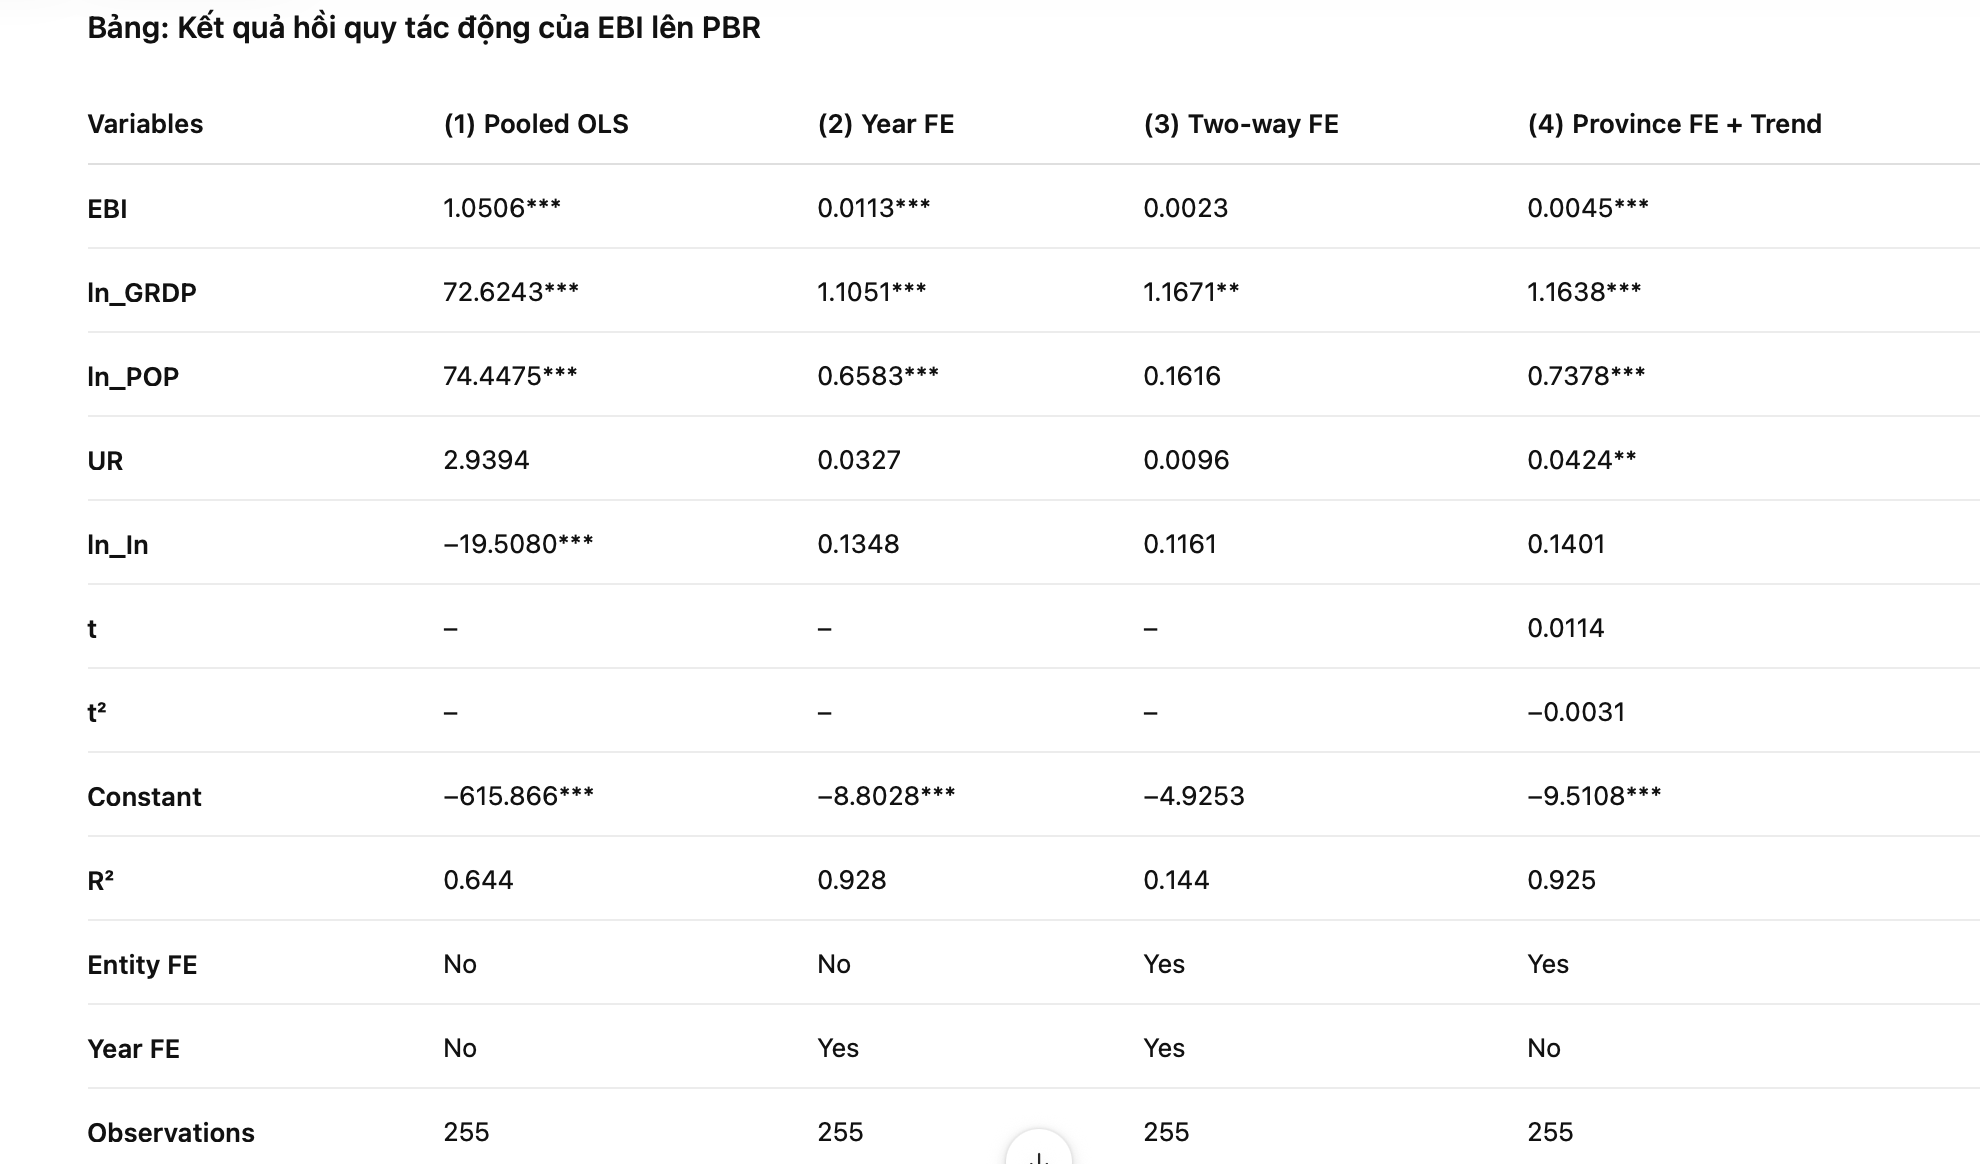

# Mediating Model

**1.  EBI_t → TC_t → PBR_t**

In [6]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# Ensure df has a MultiIndex for PanelOLS
df_panel = df.set_index(['Province', 'Year']).sort_index()

y_m = df_panel["TC"]
X_m = df_panel[["EBI", "ln_GRDP", "ln_POP", "UR","ln_In"]]
X_m = sm.add_constant(X_m)

res_m1 = PanelOLS(y_m, X_m, entity_effects=False, time_effects=True)\
        .fit(cov_type="clustered", cluster_entity=True)

print(res_m1.summary)

y = df_panel["ln_PBR"]

X = df_panel[["EBI", "TC", "ln_GRDP", "ln_POP", "UR","ln_In"]]
X = sm.add_constant(X)

model_y = PanelOLS(
    y,
    X,
    entity_effects=False,
    time_effects=True
)

res_m2 = model_y.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(res_m2.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                     TC   R-squared:                        0.1048
Estimator:                   PanelOLS   R-squared (Between):              0.2198
No. Observations:                 255   R-squared (Within):               0.0263
Date:                Wed, Mar 11 2026   R-squared (Overall):              0.1092
Time:                        14:16:36   Log-likelihood                   -260.53
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.7367
Entities:                          51   P-value                           0.0001
Avg Obs:                       5.0000   Distribution:                   F(5,245)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             3.9401
                            

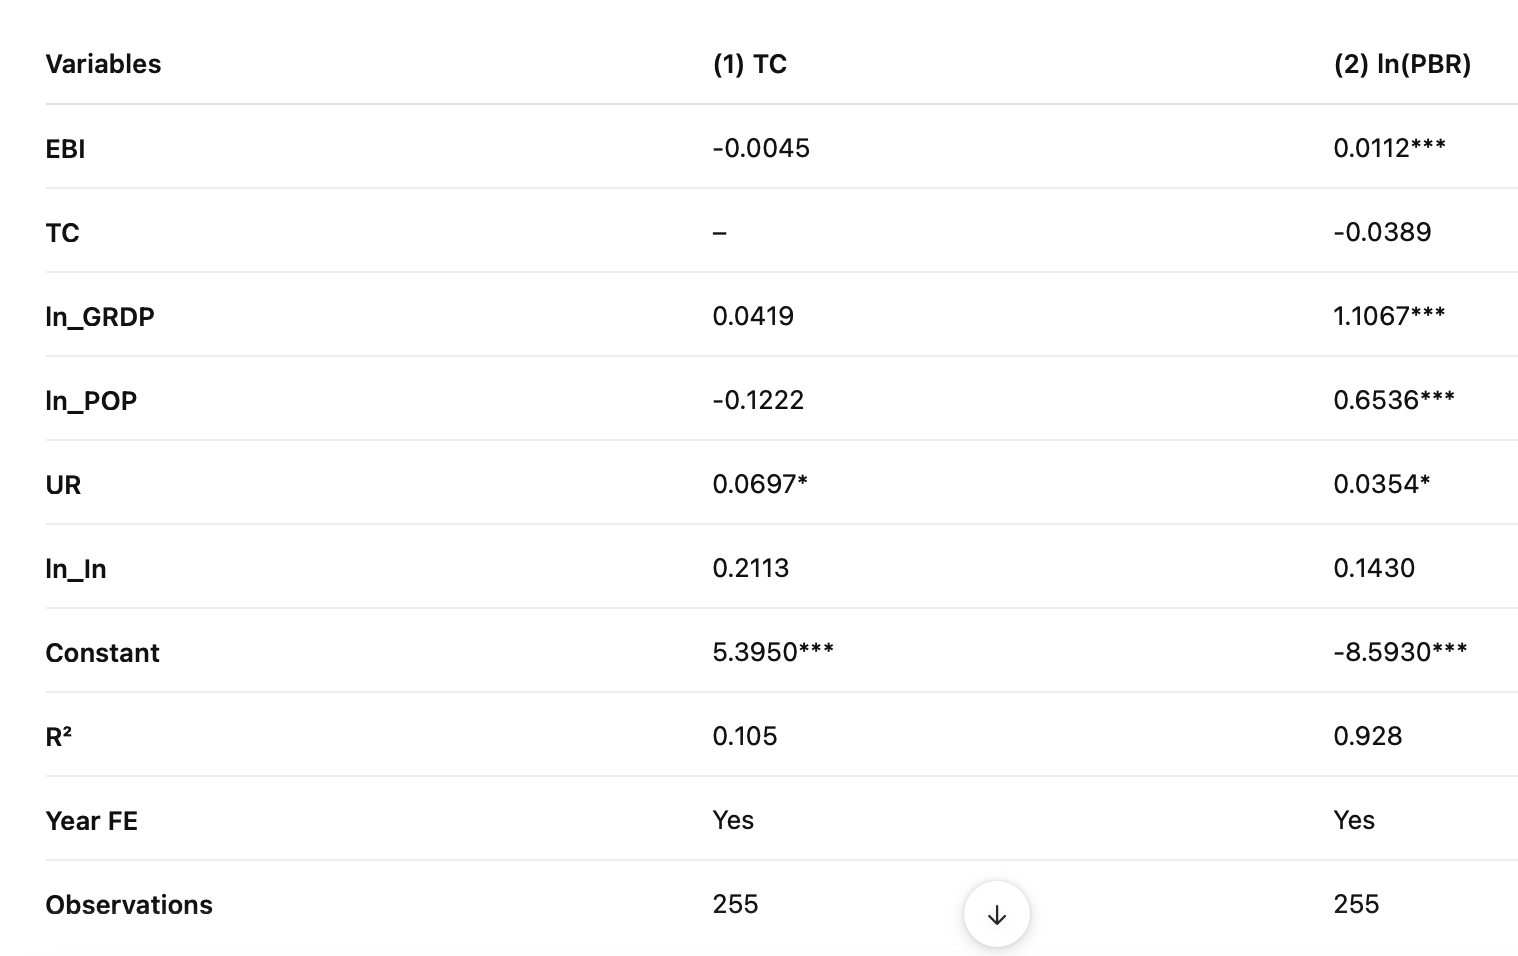

**2.  EBI_{t-1} → TC_t → PBR_t**

In [7]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

df_panel = df.set_index(["Province", "Year"]).sort_index().copy()

df_panel["EBI_l1"] = df_panel.groupby(level=0)["EBI"].shift(1)

# Model 1: EBI_{t-1} -> TC_t
data_m1 = df_panel[["TC", "EBI_l1", "ln_GRDP", "ln_POP", "UR","ln_In"]].dropna()

y_m = data_m1["TC"]
X_m = data_m1[["EBI_l1", "ln_GRDP", "ln_POP", "UR","ln_In"]]
X_m = sm.add_constant(X_m)

model_m1 = PanelOLS(
    y_m,
    X_m,
    entity_effects=False,
    time_effects=True
)

res_m1 = model_m1.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== Model 1: EBI_{t-1} -> TC_t ===")
print(res_m1.summary)


# Model 2: EBI_{t-1} + TC_t -> PBR_t
data_m2 = df_panel[["ln_PBR", "EBI_l1", "TC", "ln_GRDP", "ln_POP", "UR","ln_In"]].dropna()

y = data_m2["ln_PBR"]
X = data_m2[["EBI_l1", "TC", "ln_GRDP", "ln_POP", "UR","ln_In"]]
X = sm.add_constant(X)

model_m2 = PanelOLS(
    y,
    X,
    entity_effects=False,
    time_effects=True
)

res_m2 = model_m2.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== Model 2: EBI_{t-1} + TC_t -> ln(PBR)_t ===")
print(res_m2.summary)

=== Model 1: EBI_{t-1} -> TC_t ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                     TC   R-squared:                        0.1174
Estimator:                   PanelOLS   R-squared (Between):              0.2416
No. Observations:                 204   R-squared (Within):              -0.0204
Date:                Wed, Mar 11 2026   R-squared (Overall):              0.0929
Time:                        14:16:36   Log-likelihood                   -205.74
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.1858
Entities:                          51   P-value                           0.0002
Avg Obs:                       4.0000   Distribution:                   F(5,195)
Min Obs:                       4.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             

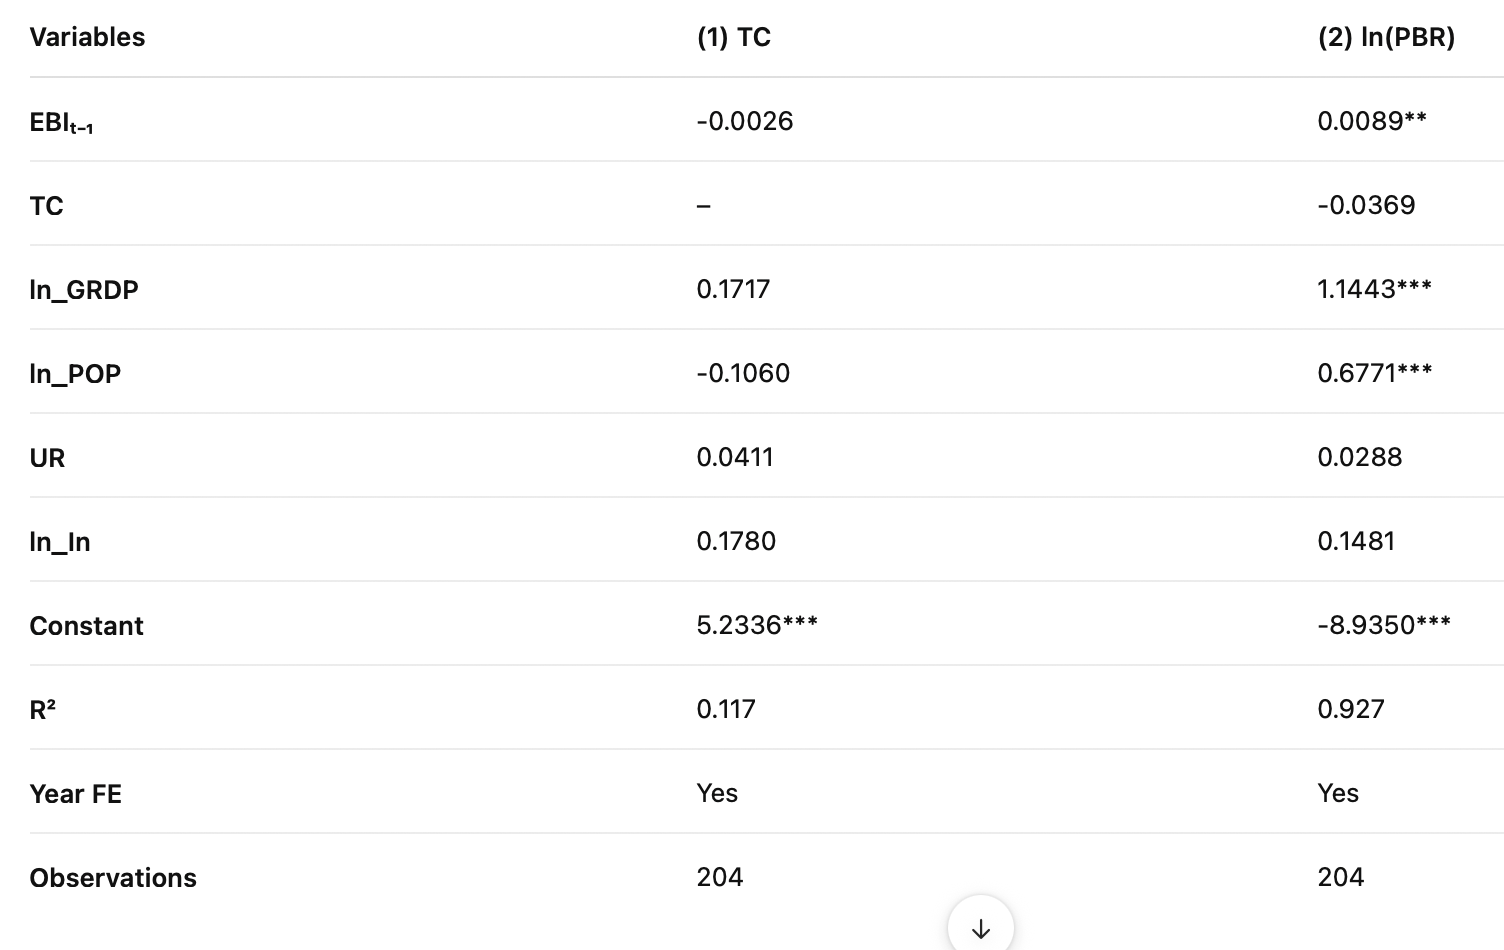

**3. EBI_{t} → TC_t → PBR_{t+1}**

In [12]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

#df_panel = df.set_index(["Province", "Year"]).sort_index().copy()

df_panel["ln_PBR_f1"] = df_panel.groupby(level=0)["ln_PBR"].shift(-1)

# Model 1: EBI_t -> TC_t
data_m1 = df_panel[["TC", "EBI", "ln_GRDP", "ln_POP", "UR","ln_In"]].dropna()

y_m = data_m1["TC"]
X_m = data_m1[["EBI", "ln_GRDP", "ln_POP", "UR","ln_In"]]
X_m = sm.add_constant(X_m)

model_m1 = PanelOLS(
    y_m,
    X_m,
    entity_effects=False,
    time_effects=True
)

res_m1 = model_m1.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== Model 1: EBI_t -> TC_t ===")
print(res_m1.summary)


# Model 2: EBI_t + TC_t -> ln(PBR)_{t+1}
data_m2 = df_panel[["ln_PBR_f1", "EBI", "TC", "ln_GRDP", "ln_POP", "UR","ln_In"]].dropna()

y = data_m2["ln_PBR_f1"]
X = data_m2[["EBI", "TC", "ln_GRDP", "ln_POP", "UR","ln_In"]]
X = sm.add_constant(X)

model_m2 = PanelOLS(
    y,
    X,
    entity_effects=False,
    time_effects=True
)

res_m2 = model_m2.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== Model 2: EBI_t + TC_t -> ln(PBR)_(t+1) ===")
print(res_m2.summary)


# Baseline: EBI_t -> ln(PBR)_{t+1}
data_base = df_panel[["ln_PBR_f1", "EBI", "ln_GRDP", "ln_POP", "UR","ln_In"]].dropna()

y_base = data_base["ln_PBR_f1"]
X_base = data_base[["EBI", "ln_GRDP", "ln_POP", "UR","ln_In"]]
X_base = sm.add_constant(X_base)

model_base = PanelOLS(
    y_base,
    X_base,
    entity_effects=False,
    time_effects=True
)

res_base = model_base.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== Baseline: EBI_t -> ln(PBR)_(t+1) ===")
print(res_base.summary)

=== Model 1: EBI_t -> TC_t ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                     TC   R-squared:                        0.1048
Estimator:                   PanelOLS   R-squared (Between):              0.2198
No. Observations:                 255   R-squared (Within):               0.0263
Date:                Wed, Mar 11 2026   R-squared (Overall):              0.1092
Time:                        14:19:42   Log-likelihood                   -260.53
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.7367
Entities:                          51   P-value                           0.0001
Avg Obs:                       5.0000   Distribution:                   F(5,245)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             3.94

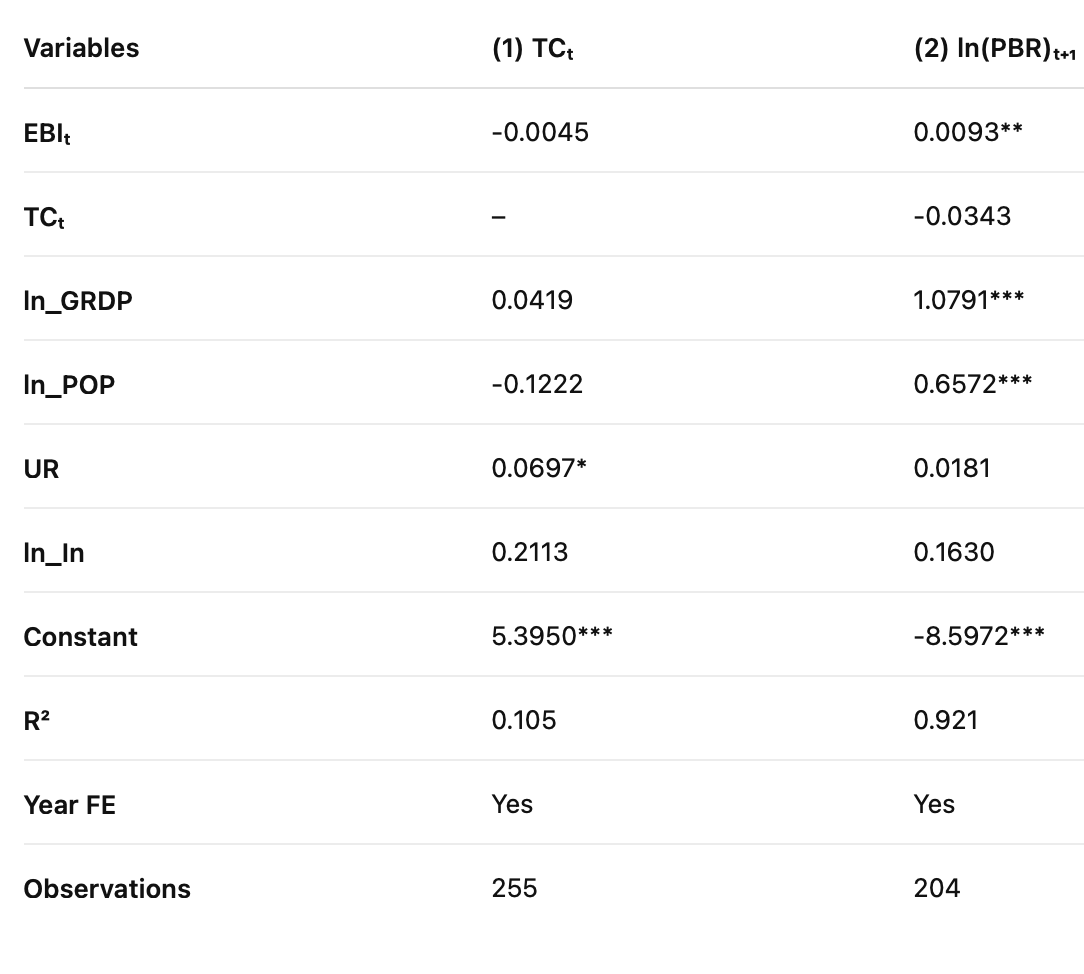

5. mediators = ["FL", "FT", "PW", "TAP","UAC"]

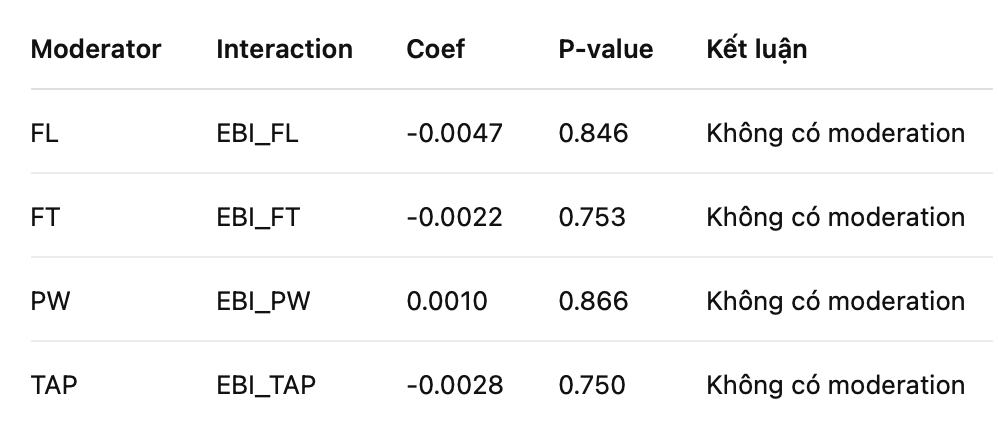

6. Par
EBI_t ->PAR_t ->ln(PBR)_t


In [10]:
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# Ensure df has MultiIndex for PanelOLS
df = df.reset_index()
df = df.set_index(["Province", "Year"]).sort_index()

# -----------------------------
# Model 0: Baseline
# EBI_t -> ln(PBR)_t
# -----------------------------
data_base = df[["ln_PBR", "EBI", "ln_GRDP", "ln_POP", "UR", "ln_In"]].dropna()

y_base = data_base["ln_PBR"]
X_base = data_base[["EBI", "ln_GRDP", "ln_POP", "UR", "ln_In"]]
X_base = sm.add_constant(X_base)

model_base = PanelOLS(
    y_base,
    X_base,
    entity_effects=False,
    time_effects=True
)

res_base = model_base.fit(
    cov_type="clustered",
    cluster_entity=False
)

print("=== Model 0: EBI_t -> ln(PBR)_t ===")
print(res_base.summary)


# -----------------------------
# Model 1: Mediator model
# EBI_t -> Par_t
# -----------------------------
data_m1 = df[["Par", "EBI", "ln_GRDP", "ln_POP", "UR", "ln_In"]].dropna()

y_m = data_m1["Par"]
X_m = data_m1[["EBI", "ln_GRDP", "ln_POP", "UR", "ln_In"]]
X_m = sm.add_constant(X_m)

model_m1 = PanelOLS(
    y_m,
    X_m,
    entity_effects=False,
    time_effects=True
)

res_m1 = model_m1.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== Model 1: EBI_t -> Par_t ===")
print(res_m1.summary)


# -----------------------------
# Model 2: Mediation model
# EBI_t + Par_t -> ln(PBR)_t
# -----------------------------
data_m2 = df[["ln_PBR", "EBI", "Par", "ln_GRDP", "ln_POP", "UR", "ln_In"]].dropna()

y = data_m2["ln_PBR"]
X = data_m2[["EBI", "Par", "ln_GRDP", "ln_POP", "UR", "ln_In"]]
X = sm.add_constant(X)

model_m2 = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=False
)

res_m2 = model_m2.fit(
    cov_type="clustered",
    cluster_entity=False
)

print("=== Model 2: EBI_t + Par_t -> ln(PBR)_t ===")
print(res_m2.summary)

=== Model 0: EBI_t -> ln(PBR)_t ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_PBR   R-squared:                        0.9278
Estimator:                   PanelOLS   R-squared (Between):              0.9428
No. Observations:                 255   R-squared (Within):              -0.0199
Date:                Wed, Mar 11 2026   R-squared (Overall):              0.9142
Time:                        14:16:36   Log-likelihood                   -38.635
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      629.91
Entities:                          51   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                   F(5,245)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):            

In [15]:
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import numpy as np

# đảm bảo panel index
df = df.reset_index()
df = df.set_index(["Province", "Year"]).sort_index()

# tạo lag
df["ln_PBR_l1"] = df.groupby(level=0)["ln_PBR"].shift(1)
df["ln_In_l1"] = df.groupby(level=0)["ln_In"].shift(1)

# bỏ NA
data = df.dropna()

################################
# MODEL 1: EBI -> TC (TC không lag)
################################

y1 = data["TC"]
X1 = data[["EBI", "ln_GRDP", "ln_POP", "UR", "ln_In_l1"]]
X1 = sm.add_constant(X1)

model1 = PanelOLS(
    y1,
    X1,
    entity_effects=True,
    time_effects=True
)

res1 = model1.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("\n=== Model 1: EBI_t -> TC_t ===")
print(res1.summary)


################################
# MODEL 2: EBI + TC -> ln(PBR_lag1)
################################

y2 = data["ln_PBR_l1"]
X2 = data[["EBI", "TC", "ln_GRDP", "ln_POP", "UR", "ln_In_l1"]]
X2 = sm.add_constant(X2)

model2 = PanelOLS(
    y2,
    X2,
    entity_effects=True,
    time_effects=True
)

res2 = model2.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("\n=== Model 2: EBI_t + TC_t -> ln(PBR)_(t-1) ===")
print(res2.summary)


=== Model 1: EBI_t -> TC_t ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                     TC   R-squared:                        0.0559
Estimator:                   PanelOLS   R-squared (Between):             -216.79
No. Observations:                 204   R-squared (Within):               0.0215
Date:                Wed, Mar 11 2026   R-squared (Overall):             -93.687
Time:                        14:27:55   Log-likelihood                   -141.43
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.7169
Entities:                          51   P-value                           0.1343
Avg Obs:                       4.0000   Distribution:                   F(5,145)
Min Obs:                       4.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             1.0

In [17]:
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# đảm bảo index panel
df = df.reset_index()
df = df.set_index(["Province", "Year"]).sort_index()

# tạo lag cho ln_In
df["ln_In_l1"] = df.groupby(level=0)["ln_In"].shift(1)

# các biến con của TC
tc_components = ["FL", "FT", "PW", "TAP"]

for tc in tc_components:

    print("\n==============================")
    print(f"MEDIATOR = {tc}_lag1")
    print("==============================")

    # tạo lag cho mediator
    df[f"{tc}_l1"] = df.groupby(level=0)[tc].shift(1)

    data = df[[
        "ln_PBR", "EBI", f"{tc}_l1",
        "ln_GRDP", "ln_POP", "UR", "ln_In_l1"
    ]].dropna()

    # -----------------------------
    # MODEL 1: EBI -> TC_component_lag1
    # -----------------------------

    y1 = data[f"{tc}_l1"]
    X1 = data[["EBI", "ln_GRDP", "ln_POP", "UR", "ln_In_l1"]]
    X1 = sm.add_constant(X1)

    model1 = PanelOLS(
        y1,
        X1,
        entity_effects=False,
        time_effects=True
    )

    res1 = model1.fit(
        cov_type="clustered",
        cluster_entity=True
    )

    print(f"\n=== Model 1: EBI_t -> {tc}_(t-1) ===")
    print(res1.summary)

    # -----------------------------
    # MODEL 2: EBI + TC_component_lag1 -> PBR
    # -----------------------------

    y2 = data["ln_PBR"]
    X2 = data[["EBI", f"{tc}_l1", "ln_GRDP", "ln_POP", "UR", "ln_In_l1"]]
    X2 = sm.add_constant(X2)

    model2 = PanelOLS(
        y2,
        X2,
        entity_effects=False,
        time_effects=True
    )

    res2 = model2.fit(
        cov_type="clustered",
        cluster_entity=True
    )

    print(f"\n=== Model 2: EBI_t + {tc}_(t-1) -> ln(PBR)_t ===")
    print(res2.summary)


MEDIATOR = FL_lag1

=== Model 1: EBI_t -> FL_(t-1) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                  FL_l1   R-squared:                        0.0661
Estimator:                   PanelOLS   R-squared (Between):             -284.19
No. Observations:                 204   R-squared (Within):               0.1270
Date:                Wed, Mar 11 2026   R-squared (Overall):             -123.51
Time:                        14:31:14   Log-likelihood                    497.09
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.0537
Entities:                          51   P-value                           0.0746
Avg Obs:                       4.0000   Distribution:                   F(5,145)
Min Obs:                       4.0000                                           
Max Obs:                       4.0000   F-statistic (

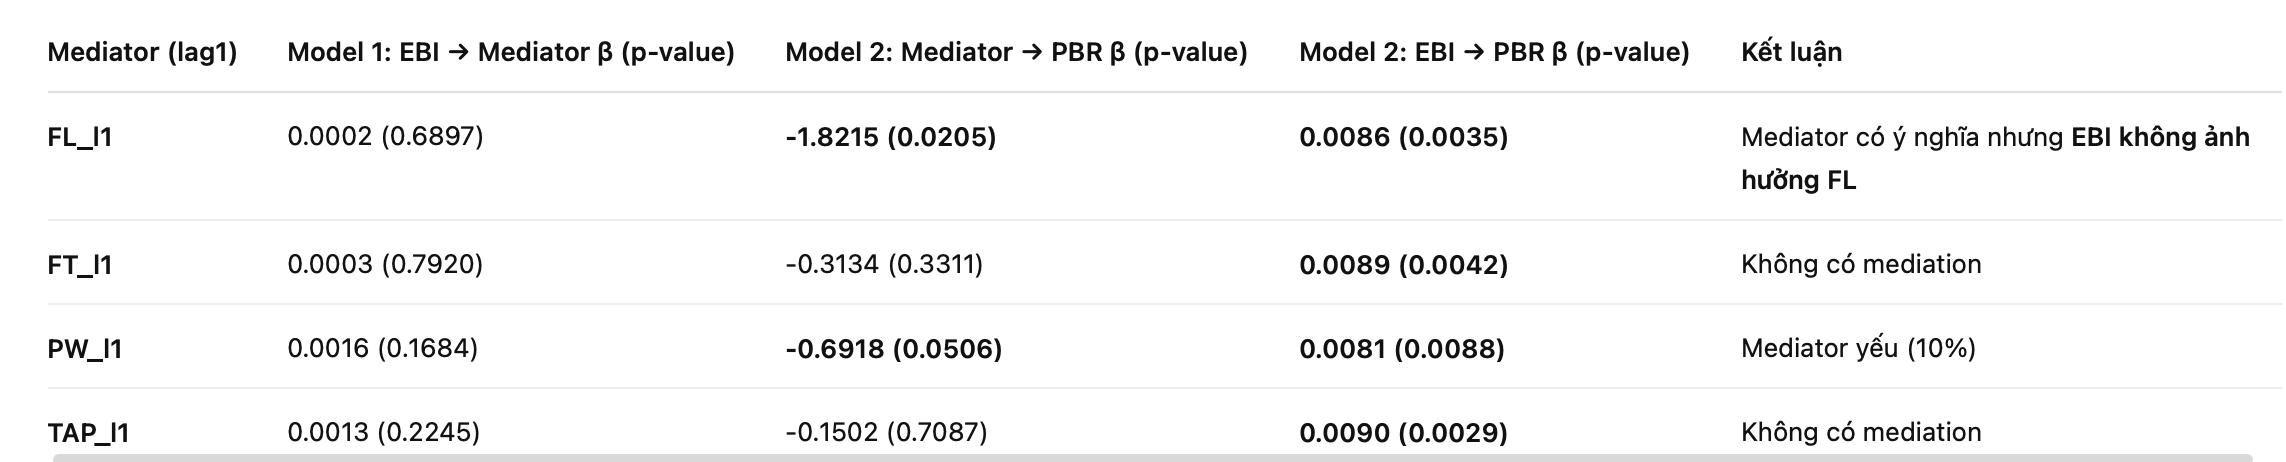